# Some Advanced Applications of Python

---

## Table of Contents

1. [The Quantum Harmonic Oscillator](#case-1-the-quantum-harmonic-oscillator)
2. [Special Functions](#case-2-special-functions)
3. [Experimental Data Fitting](#case-3-experimental-data-fitting)
4. [Monte Carlo Simulations Basics](#case-4-monte-carlo-simulations-basics)
5. [Signal Processing & FFT](#case-5-signal-processing--fft)
6. [Image Analysis](#case-6-image-analysis)
---

# Case 1: The Quantum Harmonic Oscillator

## Q1.1: Understanding the problem

The time-independent Schrödinger equation:

$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} + V(x)\psi(x) = E\psi(x)$$

For the harmonic oscillator: $V(x) = \frac{1}{2}m\omega^2x^2$

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (atomic units: ħ=m=1)
m = 1.0
omega = 1.0
hbar = 1.0

# Spatial grid
x = np.linspace(-5, 5, 200)
dx = x[1] - x[0]

print(f"Grid points: {len(x)}")
print(f"Spacing: {dx:.4f}")
print(f"Domain: [{x[0]}, {x[-1]}]")


Grid points: 200
Spacing: 0.0503
Domain: [-5.0, 5.0]


## Q1.2: Build the Hamiltonian matrix

In [59]:
def laplacian_matrix(x):
    """
    Create the finite difference Laplacian matrix

    Second derivative: d²ψ/dx² ≈ (ψ[i+1] - 2ψ[i] + ψ[i-1])/dx²

    This creates a tridiagonal matrix:
    [-2  1  0  0  ...]
    [ 1 -2  1  0  ...]
    [ 0  1 -2  1  ...]
    ...
    """
    n = len(x)
    dx = x[1] - x[0]

    # Start with -2 on diagonal
    L = -2 * np.identity(n, dtype='d')

    # Add 1 on off-diagonals
    for i in range(1, n):
        L[i, i-1] = 1.0
        L[i-1, i] = 1.0

    return L / dx**2

# Build Hamiltonian H = T + V
T = -(hbar**2 / (2*m)) * laplacian_matrix(x)  # Kinetic energy
V = 0.5 * m * omega**2 * x**2  # Potential energy
V_matrix = np.diag(V)

H = T + V_matrix

print(f"Hamiltonian shape: {H.shape}")
print(f"Hamiltonian is symmetric: {np.allclose(H, H.T)}")


Hamiltonian shape: (200, 200)
Hamiltonian is symmetric: True


## Q1.3: Solve for energy levels and wavefunctions

In [60]:
# Solve eigenvalue problem: H ψ = E ψ
energies, wavefunctions = np.linalg.eigh(H)

# The eigenvectors need normalization for finite differences
# Normalize so that ∫|ψ|² dx = 1
for i in range(wavefunctions.shape[1]):
    wavefunctions[:, i] = wavefunctions[:, i] / np.sqrt(dx)

# Show first few energy levels
print("\nLowest Energy Levels:")
print("Quantum  Numerical  Analytical  Error")
print("Number   Energy     Energy      %")
print("-" * 45)
for n in range(6):
    E_numerical = energies[n]
    E_analytical = hbar * omega * (n + 0.5)
    error = abs(E_numerical - E_analytical) / E_analytical * 100
    print(f"  n={n}    {E_numerical:.4f}     {E_analytical:.4f}      {error:.3f}%")



Lowest Energy Levels:
Quantum  Numerical  Analytical  Error
Number   Energy     Energy      %
---------------------------------------------
  n=0    0.4999     0.5000      0.016%
  n=1    1.4996     1.5000      0.026%
  n=2    2.4990     2.5000      0.041%
  n=3    3.4980     3.5000      0.056%
  n=4    4.4968     4.5000      0.072%
  n=5    5.4952     5.5000      0.086%


## Q1.4: Visualize quantum states

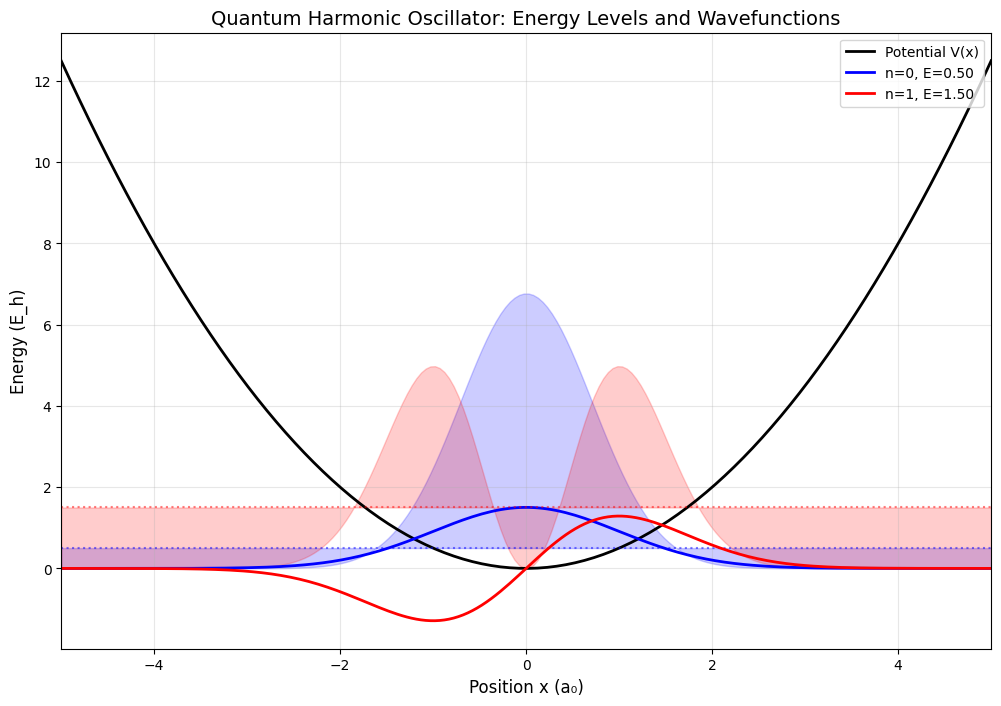

In [62]:
plt.figure(figsize=(12, 8))

# Plot potential
plt.plot(x, V, 'k-', linewidth=2, label='Potential V(x)')

# Plot first 5 energy levels and wavefunctions
n_states = 2
colors = ['blue', 'red', 'green', 'orange', 'purple']

for n in range(n_states):
    E = energies[n]
    psi = wavefunctions[:, n]

    # Energy level (horizontal line)
    plt.axhline(y=E, color=colors[n], linestyle=':', alpha=0.5)

    # Wavefunction 
    psi_scaled = 2*psi  # Scale factor for visibility
    plt.plot(x, psi_scaled, color=colors[n], linewidth=2, 
             label=f'n={n}, E={E:.2f}')

    # Probability density |ψ|² (shaded)
    plt.fill_between(x, E, psi_scaled**2 * 3, alpha=0.2, color=colors[n]) # Multiplied by 3 for visibility

plt.xlabel('Position x (a₀)', fontsize=12)
plt.ylabel('Energy (E_h)', fontsize=12)
plt.title('Quantum Harmonic Oscillator: Energy Levels and Wavefunctions', fontsize=14)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.xlim(-5, 5)
#plt.ylim(0, 6)
plt.show()


## Q1.5: Verify orthonormality
Quantum wavefunctions must be orthonormal: ⟨ψᵢ|ψⱼ⟩ = δᵢⱼ



Orthonormality Check:
⟨ψᵢ|ψⱼ⟩ for first 4 states:
[[ 1.00000000e+00 -5.55111512e-16  1.95560235e-12 -1.11022302e-16]
 [-5.55111512e-16  1.00000000e+00  1.11022302e-16  4.98961397e-11]
 [ 1.95560235e-12  1.11022302e-16  1.00000000e+00 -1.11022302e-16]
 [-1.11022302e-16  4.98961397e-11 -1.11022302e-16  9.99999999e-01]]

(Should be identity matrix)


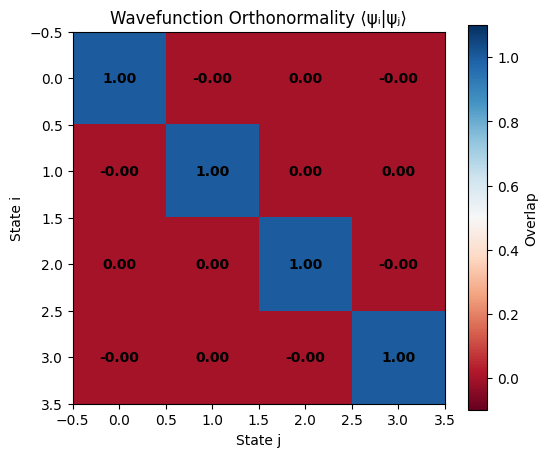

In [ ]:
# Check orthonormality
print("\nOrthonormality Check:")
print("⟨ψᵢ|ψⱼ⟩ for first 4 states:")
overlap_matrix = np.zeros((4, 4))

for i in range(4):
    for j in range(4):
        overlap = np.trapezoid(wavefunctions[:, i] * wavefunctions[:, j], x)
        overlap_matrix[i, j] = overlap

print(overlap_matrix)
print("\n(Should be identity matrix)")

# Visualize
plt.figure(figsize=(6, 5))
plt.imshow(overlap_matrix, cmap='RdBu', vmin=-0.1, vmax=1.1)
plt.colorbar(label='Overlap')
plt.title('Wavefunction Orthonormality ⟨ψᵢ|ψⱼ⟩')
plt.xlabel('State j')
plt.ylabel('State i')
for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{overlap_matrix[i,j]:.2f}', 
                ha='center', va='center', color='black', fontweight='bold')
plt.show()


---

# Case 2: Special Functions

## Q2.1: Hermite polynomials (Harmonic Oscillator)

The analytical solution to the HO uses Hermite polynomials:

$$\psi_n(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} \frac{1}{\sqrt{2^n n!}} H_n\left(\sqrt{\frac{m\omega}{\hbar}}x\right) e^{-\frac{m\omega x^2}{2\hbar}}$$



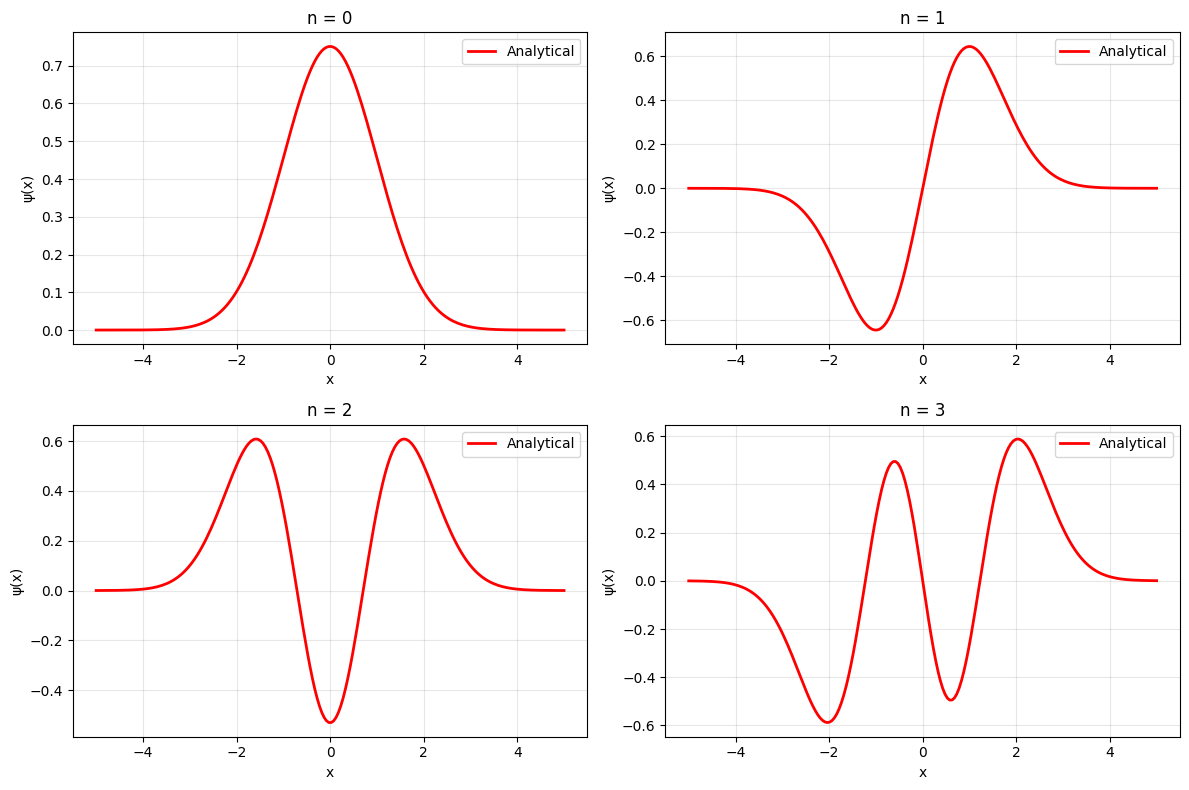

In [64]:
from numpy.polynomial.hermite import Hermite
from math import factorial

def analytical_wavefunction(x, n, m=1.0, omega=1.0, hbar=1.0):
    """Analytical HO wavefunction using Hermite polynomials"""
    # Create Hermite polynomial of order n
    coeffs = [0] * (n + 1)
    coeffs[n] = 1
    H_n = Hermite(coeffs)

    # Normalization
    norm = 1.0 / np.sqrt(2**n * factorial(n))
    norm *= (m * omega / (np.pi * hbar))**0.25

    # Scaled coordinate
    xi = np.sqrt(m * omega / hbar) * x

    # Full wavefunction
    psi = norm * H_n(xi) * np.exp(-0.5 * m * omega * x**2 / hbar)

    return psi

# Compare with numerical solution from Case 6
x = np.linspace(-5, 5, 200)
dx = x[1] - x[0]

plt.figure(figsize=(12, 8))

for n in range(4):
    plt.subplot(2, 2, n+1)

    # Analytical
    psi_analytical = analytical_wavefunction(x, n)
    plt.plot(x, psi_analytical, 'r-', linewidth=2, label='Analytical')

    # Numerical (from previous case - would need to recompute)
    # For demo, just show analytical

    plt.xlabel('x')
    plt.ylabel('ψ(x)')
    plt.title(f'n = {n}')
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()


## Q2.2: Bessel functions (Cylindrical waves)
Bessel functions appear in cylindrical coordinate problems.


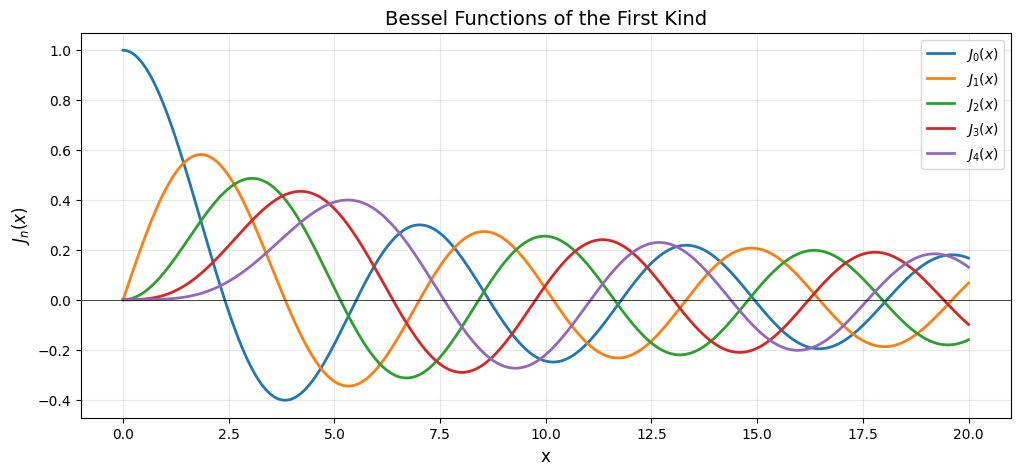

In [65]:
from scipy.special import jn  # Bessel function of first kind

x = np.linspace(0, 20, 300)

plt.figure(figsize=(12, 5))

# Plot J_n(x) for different orders
for n in range(5):
    plt.plot(x, jn(n, x), linewidth=2, label=f'$J_{n}(x)$')

plt.xlabel('x', fontsize=12)
plt.ylabel('$J_n(x)$', fontsize=12)
plt.title('Bessel Functions of the First Kind', fontsize=14)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()


## Q2.3: Legendre polynomials (Spherical harmonics)

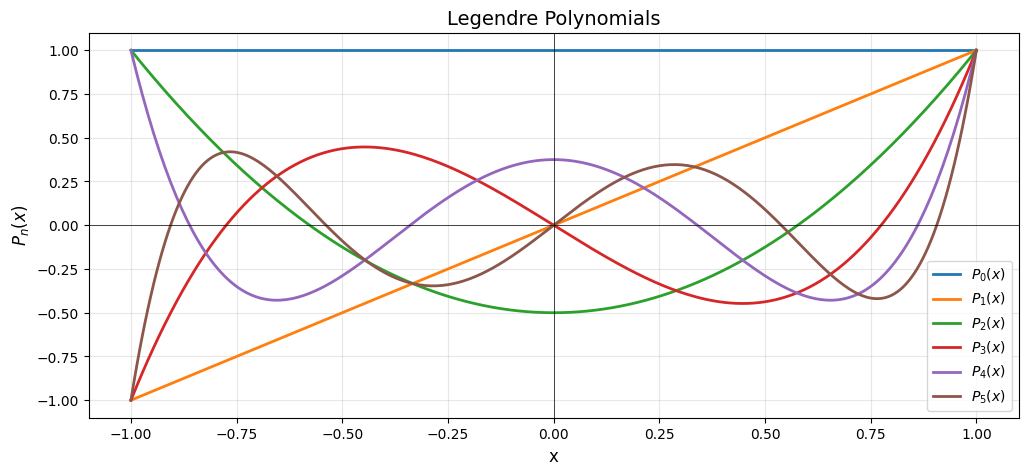

In [66]:
from scipy.special import eval_legendre

x = np.linspace(-1, 1, 300)

plt.figure(figsize=(12, 5))

for n in range(6):
    P_n = eval_legendre(n, x)
    plt.plot(x, P_n, linewidth=2, label=f'$P_{n}(x)$')

plt.xlabel('x', fontsize=12)
plt.ylabel('$P_n(x)$', fontsize=12)
plt.title('Legendre Polynomials', fontsize=14)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()


## Q2.4: Complete orthogonal function gallery

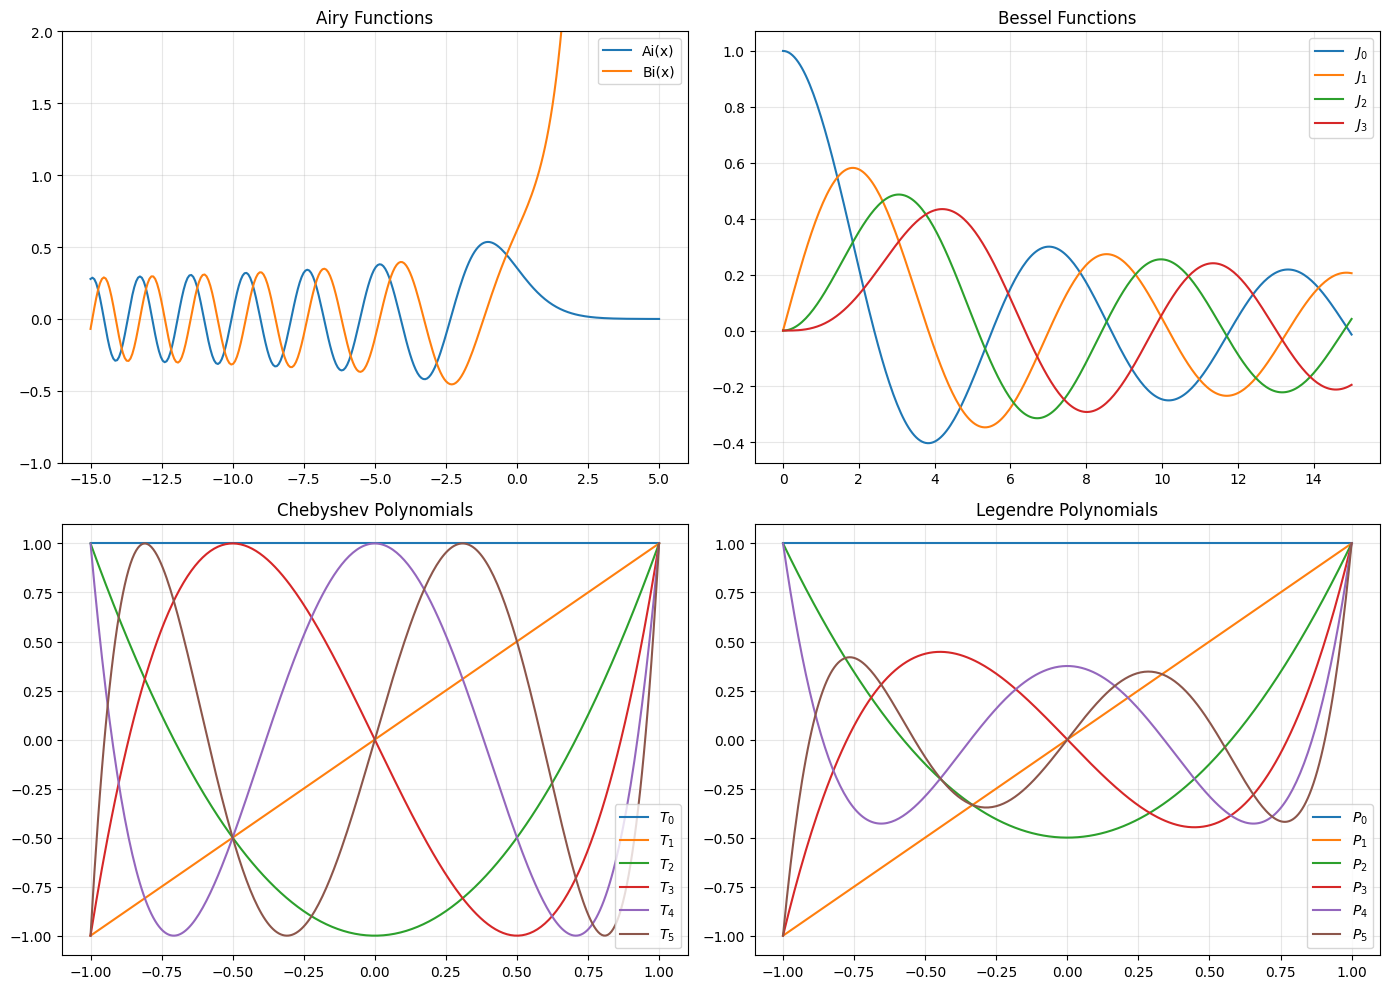

In [67]:
from scipy.special import airy, eval_chebyt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Airy functions
x_airy = np.linspace(-15, 5, 300)
Ai, Aip, Bi, Bip = airy(x_airy)
axes[0, 0].plot(x_airy, Ai, label='Ai(x)')
axes[0, 0].plot(x_airy, Bi, label='Bi(x)')
axes[0, 0].set_title('Airy Functions')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylim(-1, 2)

# Bessel functions
x_bessel = np.linspace(0, 15, 300)
for n in range(4):
    axes[0, 1].plot(x_bessel, jn(n, x_bessel), label=f'$J_{n}$')
axes[0, 1].set_title('Bessel Functions')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Chebyshev polynomials
x_cheb = np.linspace(-1, 1, 300)
for n in range(6):
    axes[1, 0].plot(x_cheb, eval_chebyt(n, x_cheb), label=f'$T_{n}$')
axes[1, 0].set_title('Chebyshev Polynomials')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Legendre polynomials
x_leg = np.linspace(-1, 1, 300)
for n in range(6):
    axes[1, 1].plot(x_leg, eval_legendre(n, x_leg), label=f'$P_{n}$')
axes[1, 1].set_title('Legendre Polynomials')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---

# Case 3: Experimental Data Fitting

## Q3.1: Exponential decay fitting

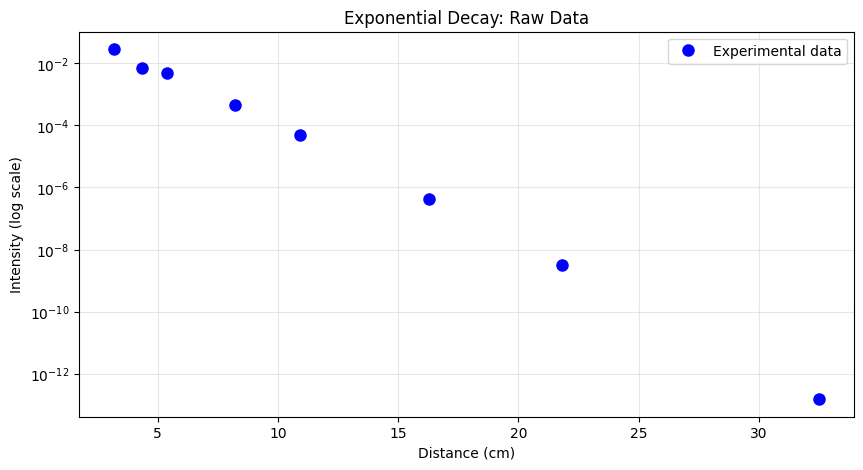

In [74]:
# Experimental data (distance vs intensity)
data_text = """3.19,0.0282
4.35,0.0072
5.37,0.0047
8.20,0.00046
10.90,0.000050
16.30,4.38e-7
21.82,3.08e-9
32.48,1.52e-13"""

# Parse data
data = []
for line in data_text.split('\n'):
    x, y = line.split(',')
    data.append([float(x), float(y)])
data = np.array(data)

x_data = data[:, 0]
y_data = data[:, 1]

plt.figure(figsize=(10, 5))
plt.semilogy(x_data, y_data, 'bo', markersize=8, label='Experimental data')
plt.xlabel('Distance (cm)')
plt.ylabel('Intensity (log scale)')
plt.title('Exponential Decay: Raw Data')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Q3.2: Linear fit to log data
For $y = A e^{ax}$, we have $\ln(y) = ax + \ln(A)$


Fitted parameters:
  Decay rate a = -0.8782 cm⁻¹
  Amplitude A = 5.2937e-01

Equation: y = 5.2937e-01 * exp(-0.8782 * x)


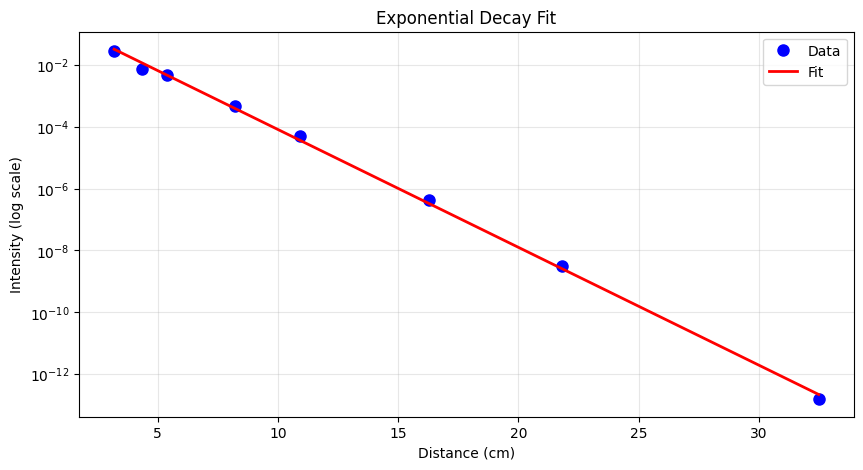

In [75]:
# Fit log(y) vs x to straight line
coeffs = np.polyfit(x_data, np.log(y_data), 1)
a = coeffs[0]  # Slope (decay rate)
logA = coeffs[1]  # Intercept
A = np.exp(logA)

print(f"Fitted parameters:")
print(f"  Decay rate a = {a:.4f} cm⁻¹")
print(f"  Amplitude A = {A:.4e}")
print(f"\nEquation: y = {A:.4e} * exp({a:.4f} * x)")

# Plot fit
x_fit = np.linspace(x_data.min(), x_data.max(), 100)
y_fit = A * np.exp(a * x_fit)

plt.figure(figsize=(10, 5))
plt.semilogy(x_data, y_data, 'bo', markersize=8, label='Data')
plt.semilogy(x_fit, y_fit, 'r-', linewidth=2, label='Fit')
plt.xlabel('Distance (cm)')
plt.ylabel('Intensity (log scale)')
plt.title('Exponential Decay Fit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Q3.3: Gaussian fitting with curve_fit

Fitted Gaussian parameters:
  Amplitude A = 29.60
  Center μ = -0.001
  Width σ = 0.223


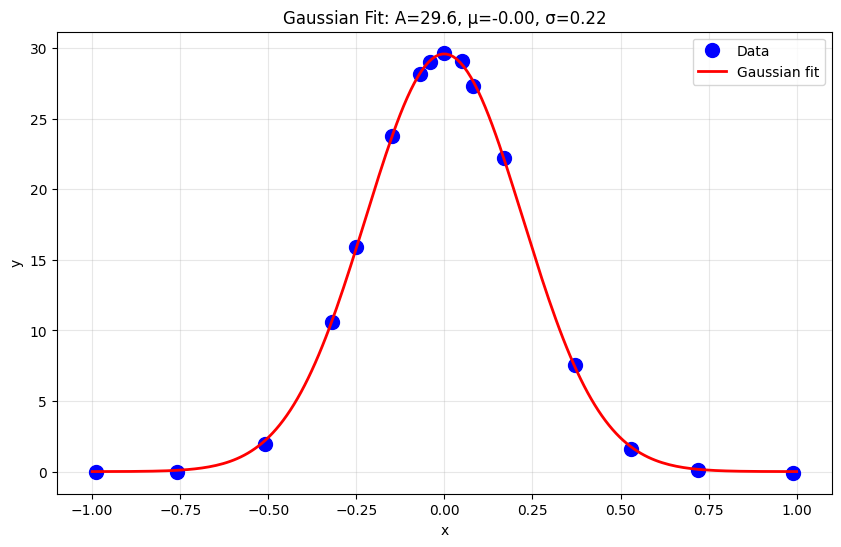

In [77]:
from scipy.optimize import curve_fit

# Gaussian data
x_gauss = np.array([-0.99, -0.76, -0.51, -0.32, -0.25, -0.15, -0.07, -0.04, 
                     0.00, 0.05, 0.08, 0.17, 0.37, 0.53, 0.72, 0.99])
y_gauss = np.array([0, 0, 1.95, 10.62, 15.89, 23.76, 28.14, 29.03, 
                     29.68, 29.11, 27.32, 22.22, 7.54, 1.62, 0.08, -0.08])

# Define Gaussian function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Fit data
initial_guess = [30, 0, 0.3]  # A, mu, sigma
params, covariance = curve_fit(gaussian, x_gauss, y_gauss, p0=initial_guess)

A_fit, mu_fit, sigma_fit = params
print(f"Fitted Gaussian parameters:")
print(f"  Amplitude A = {A_fit:.2f}")
print(f"  Center μ = {mu_fit:.3f}")
print(f"  Width σ = {sigma_fit:.3f}")

# Plot
x_smooth = np.linspace(-1, 1, 200)
y_smooth = gaussian(x_smooth, A_fit, mu_fit, sigma_fit)

plt.figure(figsize=(10, 6))
plt.plot(x_gauss, y_gauss, 'bo', markersize=10, label='Data')
plt.plot(x_smooth, y_smooth, 'r-', linewidth=2, label='Gaussian fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Gaussian Fit: A={A_fit:.1f}, μ={mu_fit:.2f}, σ={sigma_fit:.2f}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Q3.4: Polynomial fitting

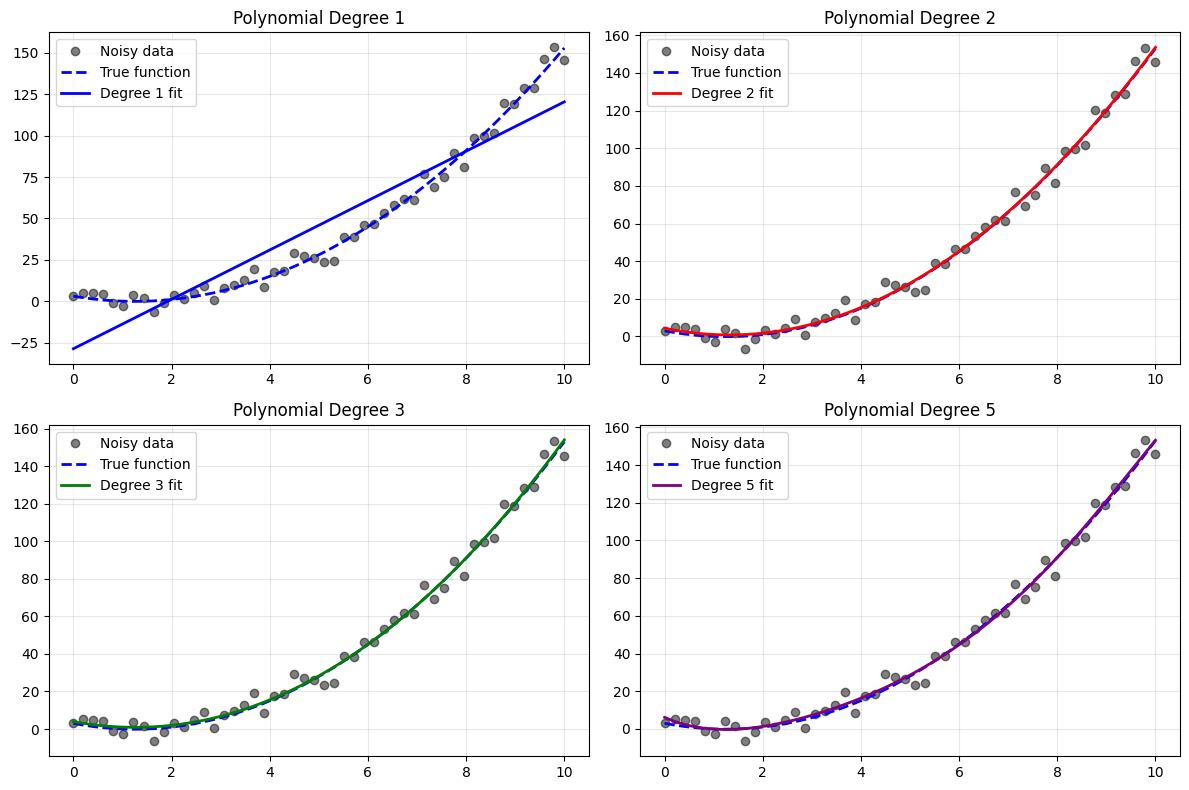

In [78]:
# Generate noisy polynomial data
x_true = np.linspace(0, 10, 50)
y_true = 2*x_true**2 - 5*x_true + 3
y_noisy = y_true + np.random.normal(0, 5, len(x_true))

# Fit polynomials of different degrees
degrees = [1, 2, 3, 5]
colors = ['blue', 'red', 'green', 'purple']

plt.figure(figsize=(12, 8))

for i, deg in enumerate(degrees):
    plt.subplot(2, 2, i+1)

    # Fit
    coeffs = np.polyfit(x_true, y_noisy, deg)
    poly = np.poly1d(coeffs)

    # Plot
    plt.plot(x_true, y_noisy, 'ko', alpha=0.5, label='Noisy data')
    plt.plot(x_true, y_true, 'b--', linewidth=2, label='True function')

    x_fit = np.linspace(0, 10, 200)
    plt.plot(x_fit, poly(x_fit), color=colors[i], linewidth=2, label=f'Degree {deg} fit')

    plt.title(f'Polynomial Degree {deg}')
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---

# Case 4: Monte Carlo Simulations Basics

## Q4.1: Random number basics

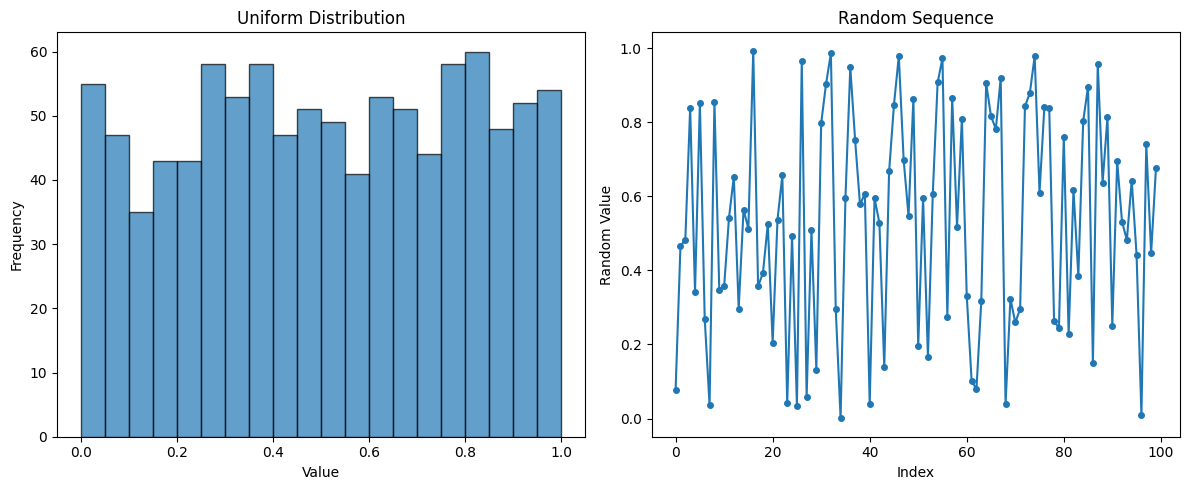

In [79]:
# Uniform random numbers [0, 1)
random_uniform = np.random.rand(1000)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(random_uniform, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Uniform Distribution')

plt.subplot(1, 2, 2)
plt.plot(random_uniform[:100], 'o-', markersize=4)
plt.xlabel('Index')
plt.ylabel('Random Value')
plt.title('Random Sequence')

plt.tight_layout()
plt.show()


## Q4.2: Normal distribution

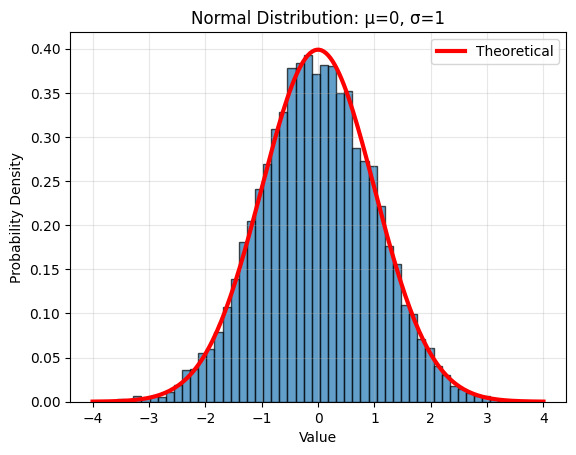

Sample mean: -0.0197 (expected: 0)
Sample std: 1.0069 (expected: 1)


In [80]:
# Normal distribution: mean=0, std=1
mu, sigma = 0, 1
samples = np.random.normal(mu, sigma, 10000)

# Plot histogram
count, bins, _ = plt.hist(samples, bins=50, density=True, alpha=0.7, edgecolor='black')

# Theoretical curve
x_theory = np.linspace(-4, 4, 200)
y_theory = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_theory - mu) / sigma)**2)

plt.plot(x_theory, y_theory, 'r-', linewidth=3, label='Theoretical')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title(f'Normal Distribution: μ={mu}, σ={sigma}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Sample mean: {np.mean(samples):.4f} (expected: {mu})")
print(f"Sample std: {np.std(samples):.4f} (expected: {sigma})")


## Q4.3: Computing π with Monte Carlo
**Method:** Sample random points in a square. Count how many fall inside the inscribed circle.

$$\frac{\text{Points in circle}}{\text{Total points}} \approx \frac{\pi r^2}{(2r)^2} = \frac{\pi}{4}$$


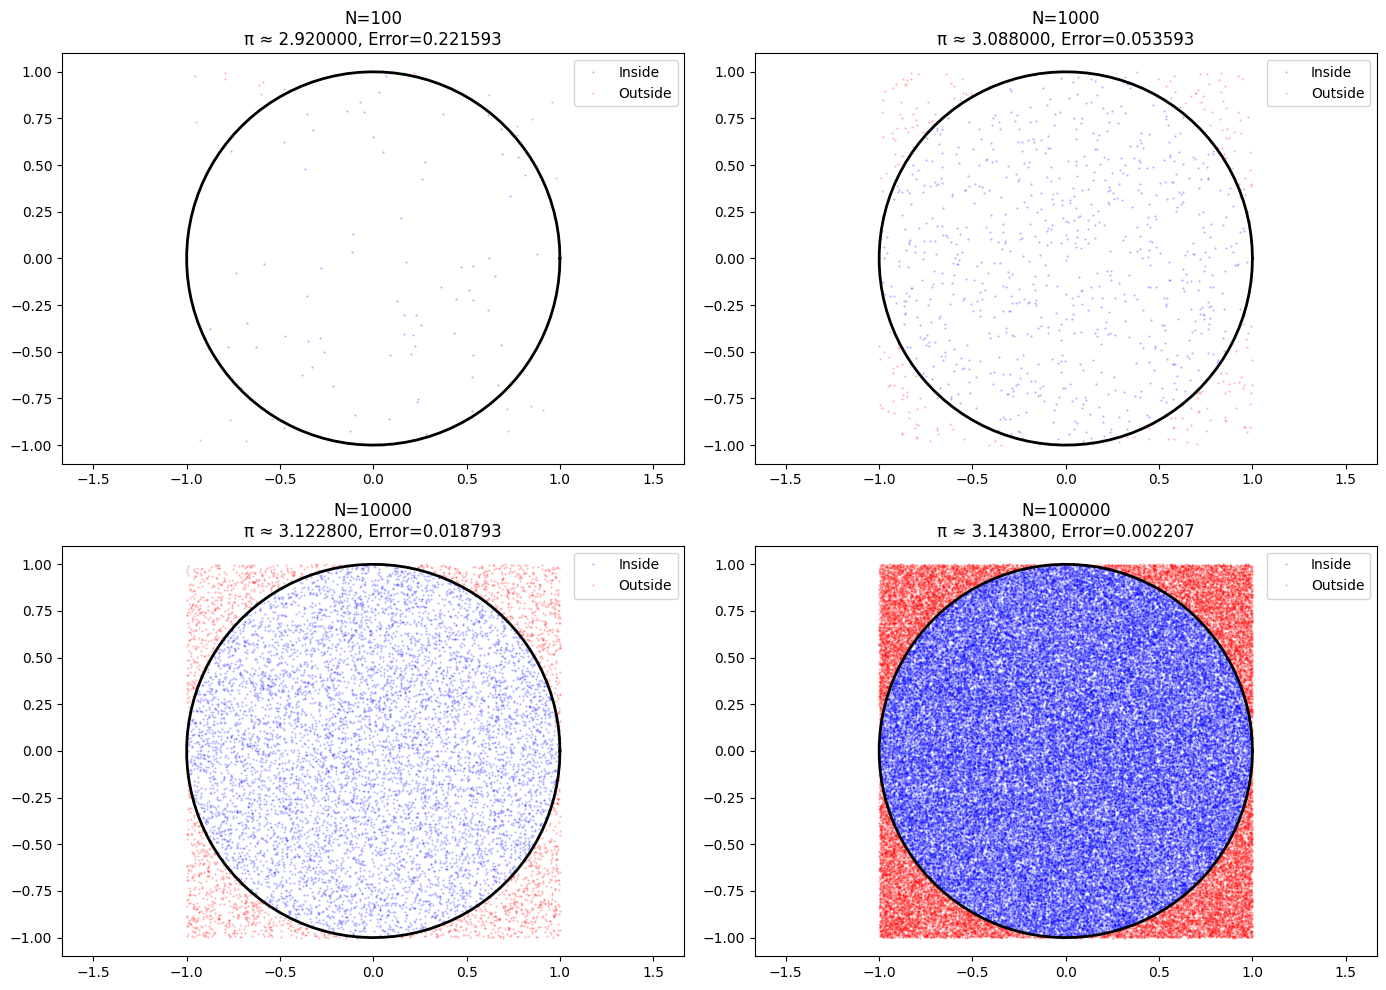

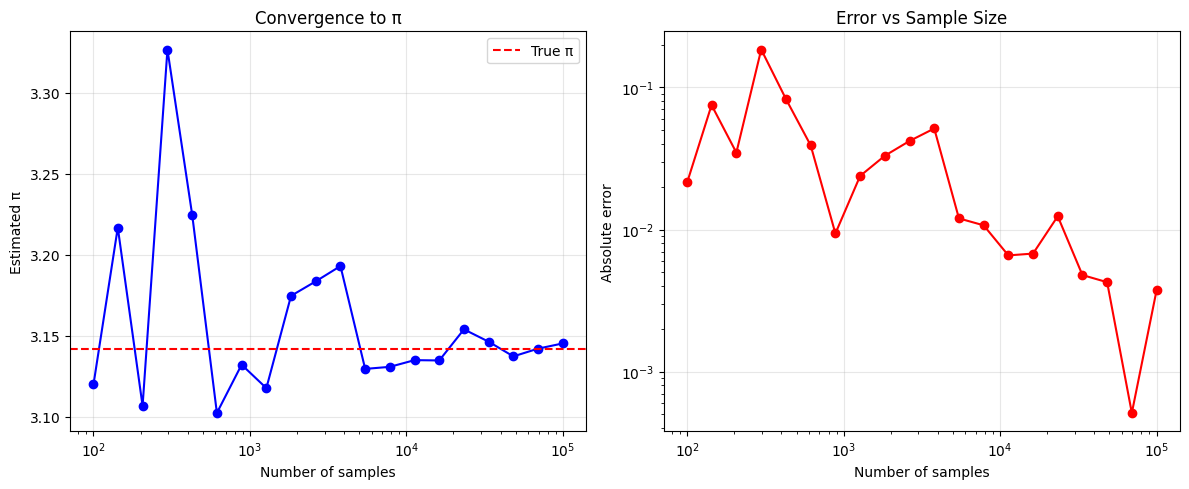

In [81]:
def compute_pi_monte_carlo(n_points):
    """Estimate π using Monte Carlo method"""
    # Random points in [-1, 1] × [-1, 1]
    x = 2 * np.random.rand(n_points) - 1
    y = 2 * np.random.rand(n_points) - 1

    # Distance from origin
    r_squared = x**2 + y**2

    # Count points inside unit circle
    inside = r_squared < 1
    n_inside = np.sum(inside)

    # Estimate π
    pi_estimate = 4 * n_inside / n_points

    return pi_estimate, x, y, inside

# Compute with different sample sizes
n_trials = [100, 1000, 10000, 100000]

plt.figure(figsize=(14, 10))

for i, n in enumerate(n_trials):
    pi_est, x, y, inside = compute_pi_monte_carlo(n)
    error = abs(pi_est - np.pi)

    plt.subplot(2, 2, i+1)

    # Plot points
    plt.plot(x[inside], y[inside], 'b.', markersize=1, alpha=0.3, label='Inside')
    plt.plot(x[~inside], y[~inside], 'r.', markersize=1, alpha=0.3, label='Outside')

    # Draw circle
    theta = np.linspace(0, 2*np.pi, 100)
    plt.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2)

    plt.axis('equal')
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.title(f'N={n}\nπ ≈ {pi_est:.6f}, Error={error:.6f}')
    plt.legend()

plt.tight_layout()
plt.show()

# Convergence study
n_values = np.logspace(2, 5, 20).astype(int)
pi_estimates = []
errors = []

for n in n_values:
    pi_est, _, _, _ = compute_pi_monte_carlo(n)
    pi_estimates.append(pi_est)
    errors.append(abs(pi_est - np.pi))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogx(n_values, pi_estimates, 'bo-')
plt.axhline(y=np.pi, color='r', linestyle='--', label='True π')
plt.xlabel('Number of samples')
plt.ylabel('Estimated π')
plt.title('Convergence to π')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.loglog(n_values, errors, 'ro-')
plt.xlabel('Number of samples')
plt.ylabel('Absolute error')
plt.title('Error vs Sample Size')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Key Insight:** Monte Carlo error decreases as $1/\sqrt{N}$. Need 100× more samples for 10× better accuracy!

---


# Case 5: Signal Processing & FFT 

## Q5.1: Creating a test signal

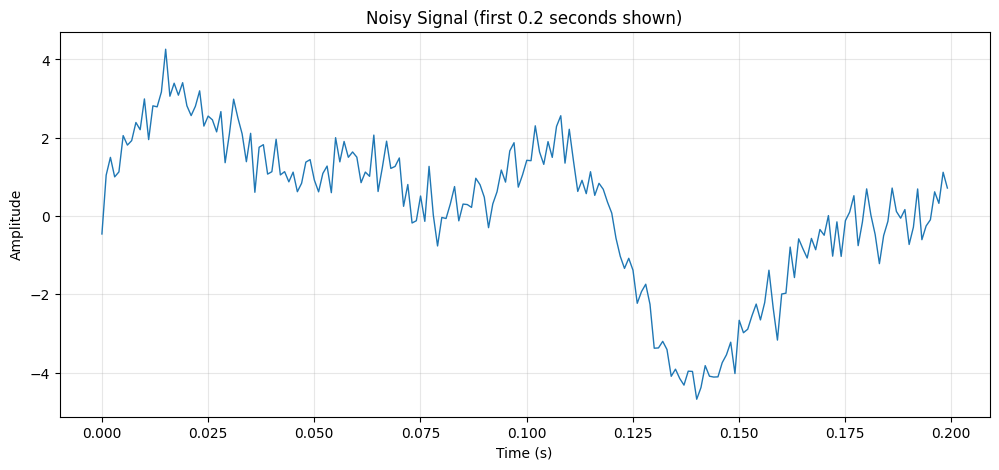

Sampling rate: 1000 Hz
Duration: 2.0 s
Hidden frequencies: 5, 12, 20 Hz


In [82]:
from scipy.fftpack import fft, fftfreq

# Time array
t = np.linspace(0, 2, 2000)  # 2 seconds, 2000 points
dt = t[1] - t[0]
sampling_rate = 1 / dt

# Create signal: mix of 3 frequencies + noise
f1, f2, f3 = 5, 12, 20  # Hz
signal = (2.0 * np.sin(2*np.pi*f1*t) + 
          1.5 * np.sin(2*np.pi*f2*t) + 
          1.0 * np.sin(2*np.pi*f3*t) +
          0.5 * np.random.randn(len(t)))

plt.figure(figsize=(12, 5))
plt.plot(t[:200], signal[:200], linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Noisy Signal (first 0.2 seconds shown)')
plt.grid(alpha=0.3)
plt.show()

print(f"Sampling rate: {sampling_rate:.0f} Hz")
print(f"Duration: {t[-1]:.1f} s")
print(f"Hidden frequencies: {f1}, {f2}, {f3} Hz")


## Q5.2: Fourier Transform - Find hidden frequencies!

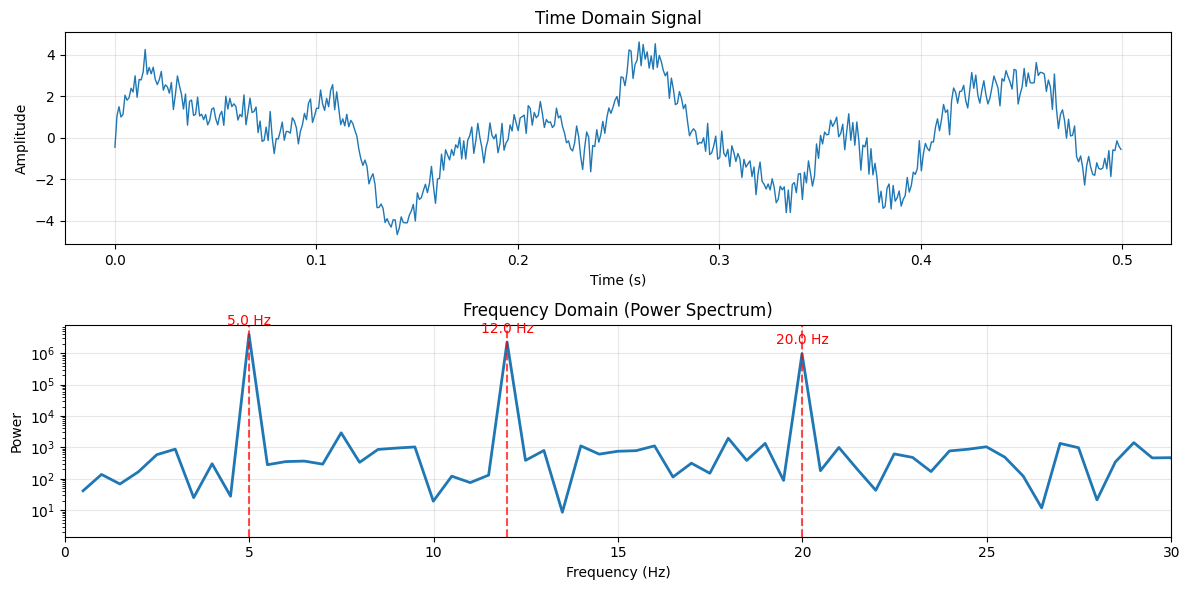


Detected peak frequencies:
  19.99 Hz
  11.99 Hz
  5.00 Hz


In [83]:
# Compute FFT
FFT = fft(signal)
frequencies = fftfreq(len(t), dt)

# Power spectrum (magnitude squared)
power = np.abs(FFT)**2

# Only positive frequencies
positive_freq_idx = frequencies > 0
freqs_positive = frequencies[positive_freq_idx]
power_positive = power[positive_freq_idx]

# Plot
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t[:500], signal[:500], linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Time Domain Signal')
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.semilogy(freqs_positive, power_positive, linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Frequency Domain (Power Spectrum)')
plt.xlim(0, 30)
plt.grid(alpha=0.3)

# Mark the peaks
peaks_idx = np.argsort(power_positive)[-3:]  # Top 3 peaks
for idx in peaks_idx:
    f_peak = freqs_positive[idx]
    if f_peak < 30:
        plt.axvline(x=f_peak, color='r', linestyle='--', alpha=0.7)
        plt.text(f_peak, power_positive[idx]*2, f'{f_peak:.1f} Hz', 
                ha='center', fontsize=10, color='red')

plt.tight_layout()
plt.show()

print("\nDetected peak frequencies:")
for idx in peaks_idx:
    f_peak = freqs_positive[idx]
    if f_peak < 30:
        print(f"  {f_peak:.2f} Hz")


## Q5.3: Filtering - Remove noise

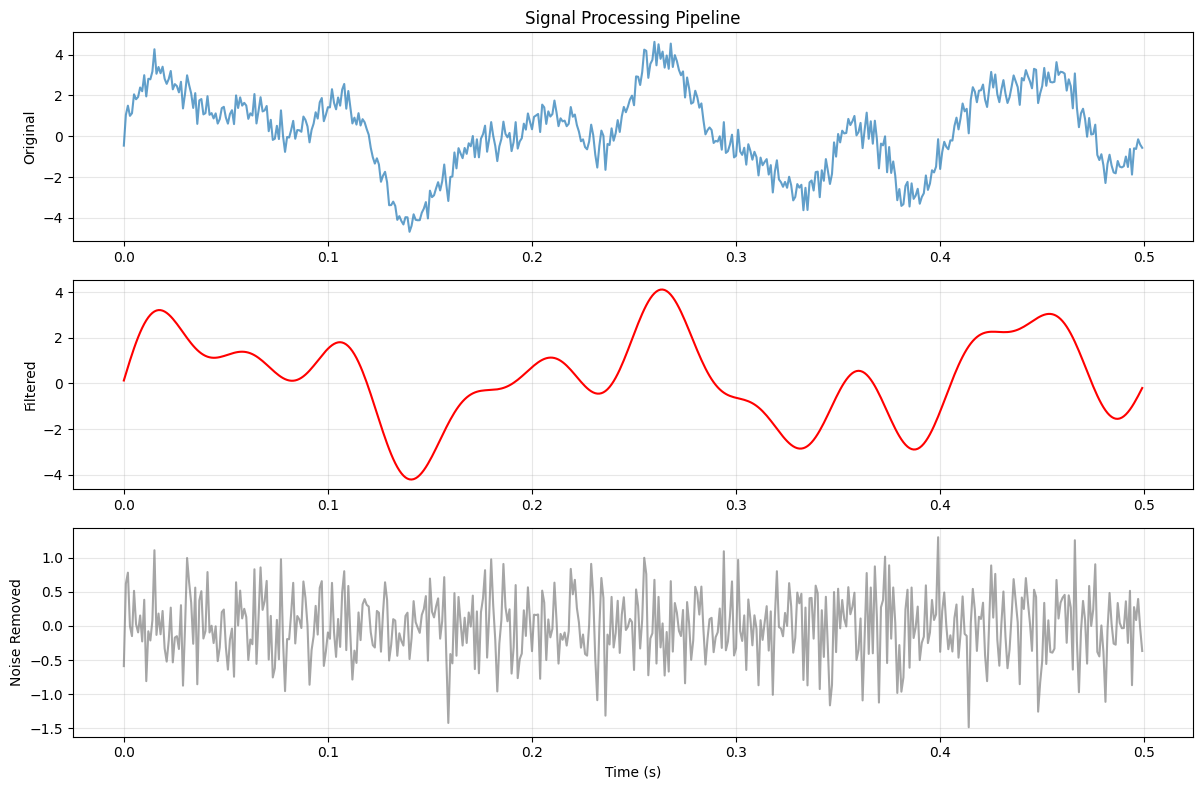

In [84]:
# Low-pass filter: keep only frequencies below cutoff
cutoff_freq = 25  # Hz
FFT_filtered = FFT.copy()
FFT_filtered[np.abs(frequencies) > cutoff_freq] = 0

# Inverse FFT to get filtered signal
signal_filtered = np.real(np.fft.ifft(FFT_filtered))

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t[:500], signal[:500], alpha=0.7)
plt.ylabel('Original')
plt.title('Signal Processing Pipeline')
plt.grid(alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(t[:500], signal_filtered[:500], color='red')
plt.ylabel('Filtered')
plt.grid(alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(t[:500], signal[:500] - signal_filtered[:500], color='gray', alpha=0.7)
plt.ylabel('Noise Removed')
plt.xlabel('Time (s)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Q5.4: Real-world application - ECG/Audio

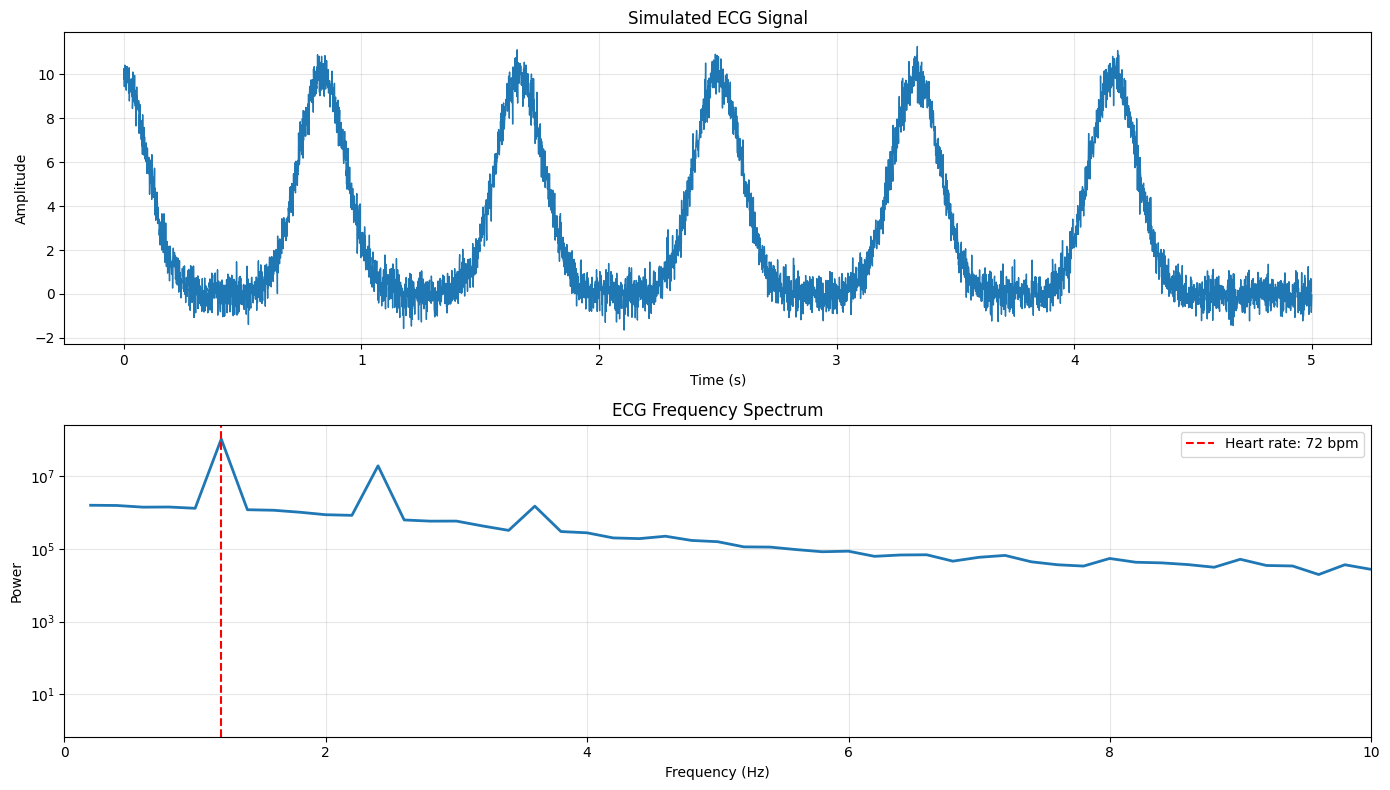

In [85]:
# Simulate a "heartbeat" signal
t_ecg = np.linspace(0, 5, 5000)
heart_rate = 72  # bpm = 1.2 Hz

# Simplified ECG: periodic spikes + baseline + noise
ecg = np.zeros_like(t_ecg)
beat_times = np.arange(0, 5, 1/(heart_rate/60))

for beat_time in beat_times:
    # Gaussian spike for each beat
    ecg += 10 * np.exp(-50*(t_ecg - beat_time)**2)

# Add noise
ecg += 0.5 * np.random.randn(len(t_ecg))

# FFT analysis
FFT_ecg = fft(ecg)
freq_ecg = fftfreq(len(t_ecg), t_ecg[1]-t_ecg[0])

plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(t_ecg, ecg, linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Simulated ECG Signal')
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.semilogy(freq_ecg[freq_ecg>0], np.abs(FFT_ecg[freq_ecg>0])**2, linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('ECG Frequency Spectrum')
plt.xlim(0, 10)
plt.axvline(x=heart_rate/60, color='r', linestyle='--', label=f'Heart rate: {heart_rate} bpm')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---

# Case 6: Image Analysis

## Q6.1: Understanding image structure

Image shape: (3888, 5184, 3)
Data type: uint8
Height: 3888 pixels
Width: 5184 pixels
Channels: 3 (RGB)

Memory size: 59049.0 KB


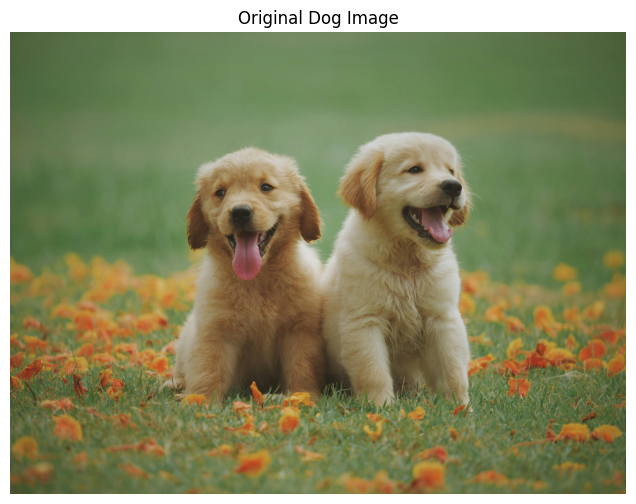

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the actual dog image
dog_img = Image.open('dogs.jpg') # pathway/dogs.jpg # pwd in terminal tells you the path to that folder
image_array = np.array(dog_img)

print(f"Image shape: {image_array.shape}")
print(f"Data type: {image_array.dtype}")
print(f"Height: {image_array.shape[0]} pixels")
print(f"Width: {image_array.shape[1]} pixels")
print(f"Channels: {image_array.shape[2]} (RGB)")
print(f"\nMemory size: {image_array.nbytes / 1024:.1f} KB")

# Display the original image
plt.figure(figsize=(10, 6))
plt.imshow(image_array)
plt.title('Original Dog Image')
plt.axis('off')
plt.show()

## Q6.2: Creating and manipulating images

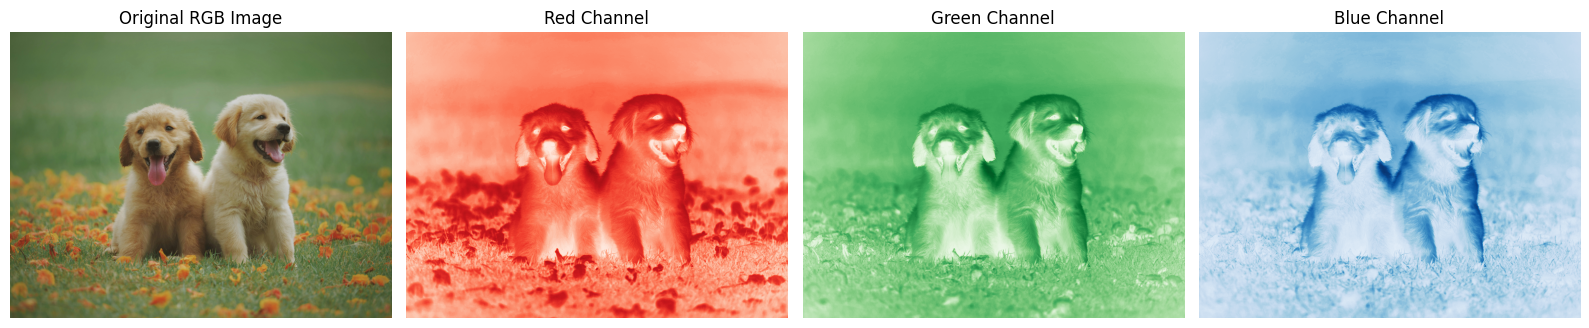

In [87]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(image_array)
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(image_array[:, :, 0], cmap='Reds')
plt.title('Red Channel')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(image_array[:, :, 1], cmap='Greens')
plt.title('Green Channel')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(image_array[:, :, 2], cmap='Blues')
plt.title('Blue Channel')
plt.axis('off')

plt.tight_layout()
plt.show()


# Q6.3: Image transformations

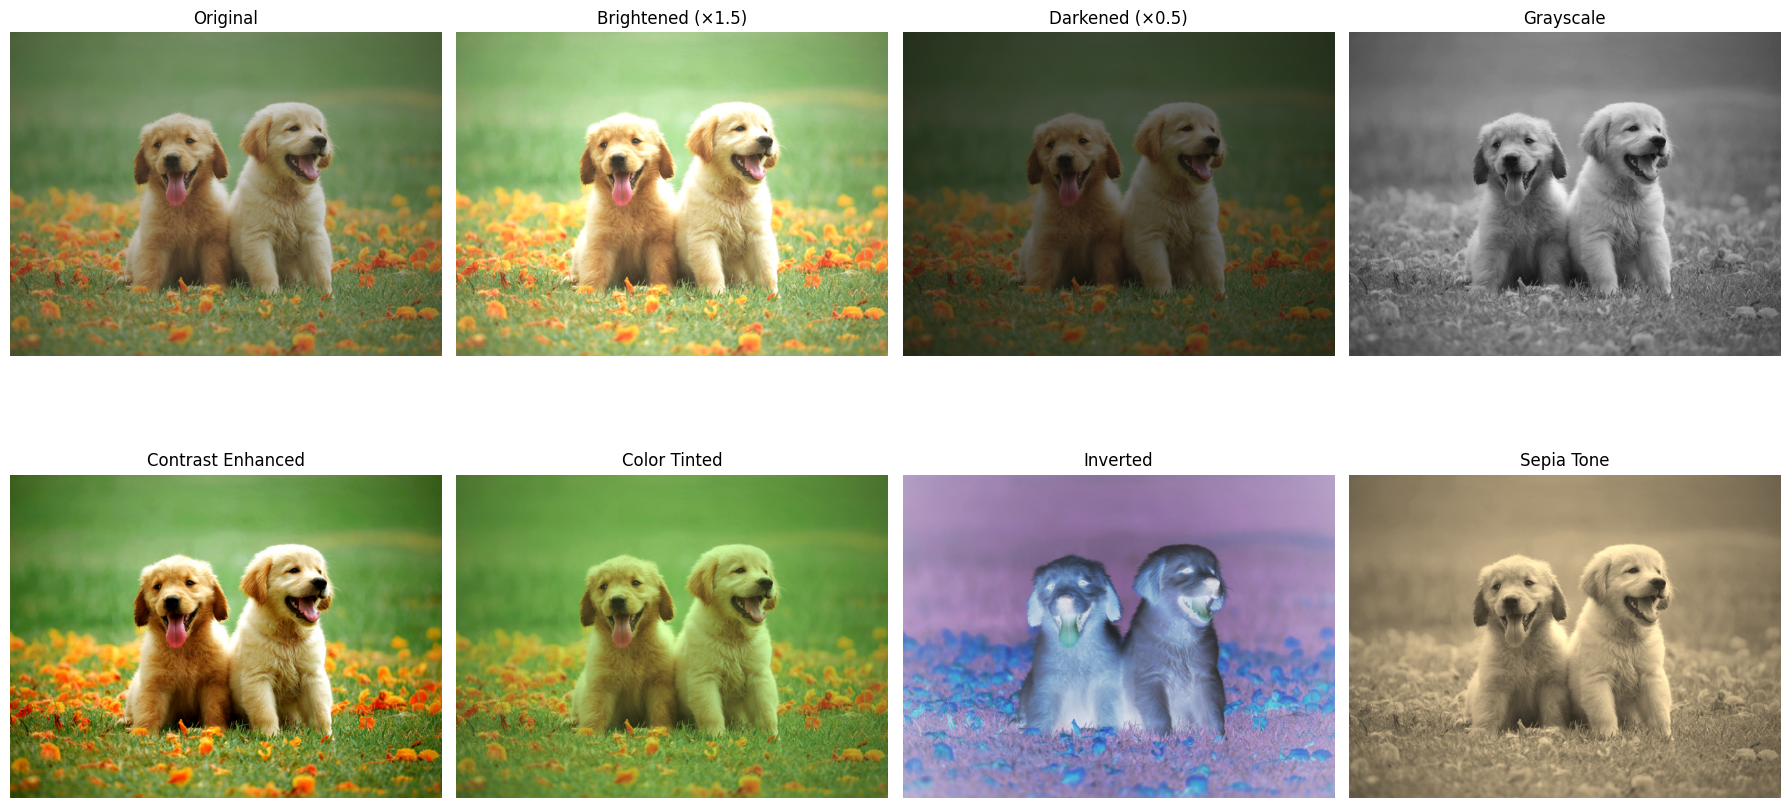

In [88]:
plt.figure(figsize=(18, 10))

# Original
plt.subplot(2, 4, 1)
plt.imshow(image_array)
plt.title('Original')
plt.axis('off')

# Brightness adjustment
brighter = np.clip(image_array.astype(float) * 1.5, 0, 255).astype(np.uint8)
plt.subplot(2, 4, 2)
plt.imshow(brighter)
plt.title('Brightened (×1.5)')
plt.axis('off')

# Darker
darker = np.clip(image_array.astype(float) * 0.5, 0, 255).astype(np.uint8)
plt.subplot(2, 4, 3)
plt.imshow(darker)
plt.title('Darkened (×0.5)')
plt.axis('off')

# Grayscale conversion
gray = np.dot(image_array[...,:3], [0.299, 0.587, 0.114])
plt.subplot(2, 4, 4)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

# Contrast stretching
p2, p98 = np.percentile(image_array, (2, 98))
stretched = np.clip((image_array - p2) / (p98 - p2) * 255, 0, 255).astype(np.uint8)
plt.subplot(2, 4, 5)
plt.imshow(stretched)
plt.title('Contrast Enhanced')
plt.axis('off')

# Color tinting
tinted = image_array.copy().astype(float)
tinted = tinted * [1.0, 1.2, 0.8]  # Boost green, reduce blue
tinted = np.clip(tinted, 0, 255).astype(np.uint8)
plt.subplot(2, 4, 6)
plt.imshow(tinted)
plt.title('Color Tinted')
plt.axis('off')

# Inverted colors
inverted = 255 - image_array
plt.subplot(2, 4, 7)
plt.imshow(inverted)
plt.title('Inverted')
plt.axis('off')

# Sepia effect
sepia_filter = np.array([[0.393, 0.769, 0.189],
                         [0.349, 0.686, 0.168],
                         [0.272, 0.534, 0.131]])
sepia = image_array.dot(sepia_filter.T)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)
plt.subplot(2, 4, 8)
plt.imshow(sepia)
plt.title('Sepia Tone')
plt.axis('off')

plt.tight_layout()
plt.show()


## Q6.4: Image analysis - Histogram

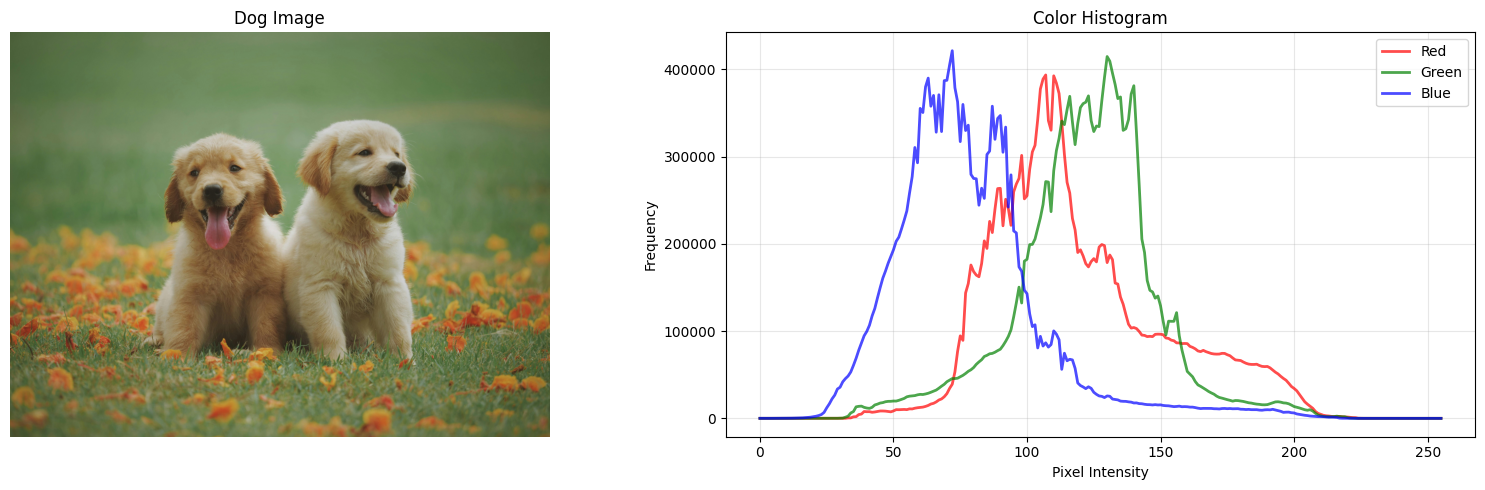


Color Channel Statistics:
Red    - Mean: 119.3, Std: 32.2, Min: 21, Max: 243
Green  - Mean: 122.0, Std: 26.2, Min: 18, Max: 233
Blue   - Mean: 78.3, Std: 27.6, Min: 0, Max: 221


In [89]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title('Dog Image')
plt.axis('off')

plt.subplot(1, 2, 2)
colors = ['red', 'green', 'blue']
for i, color in enumerate(colors):
    hist, bins = np.histogram(image_array[:, :, i].flatten(), bins=256, range=(0, 256))
    plt.plot(bins[:-1], hist, color=color, linewidth=2, label=color.capitalize(), alpha=0.7)

plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Color Histogram')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print color statistics
print("\nColor Channel Statistics:")
for i, color in enumerate(['Red', 'Green', 'Blue']):
    channel = image_array[:, :, i]
    print(f"{color:6s} - Mean: {channel.mean():.1f}, Std: {channel.std():.1f}, "
          f"Min: {channel.min()}, Max: {channel.max()}")


## Q6.5: Practical example - Image enhancement

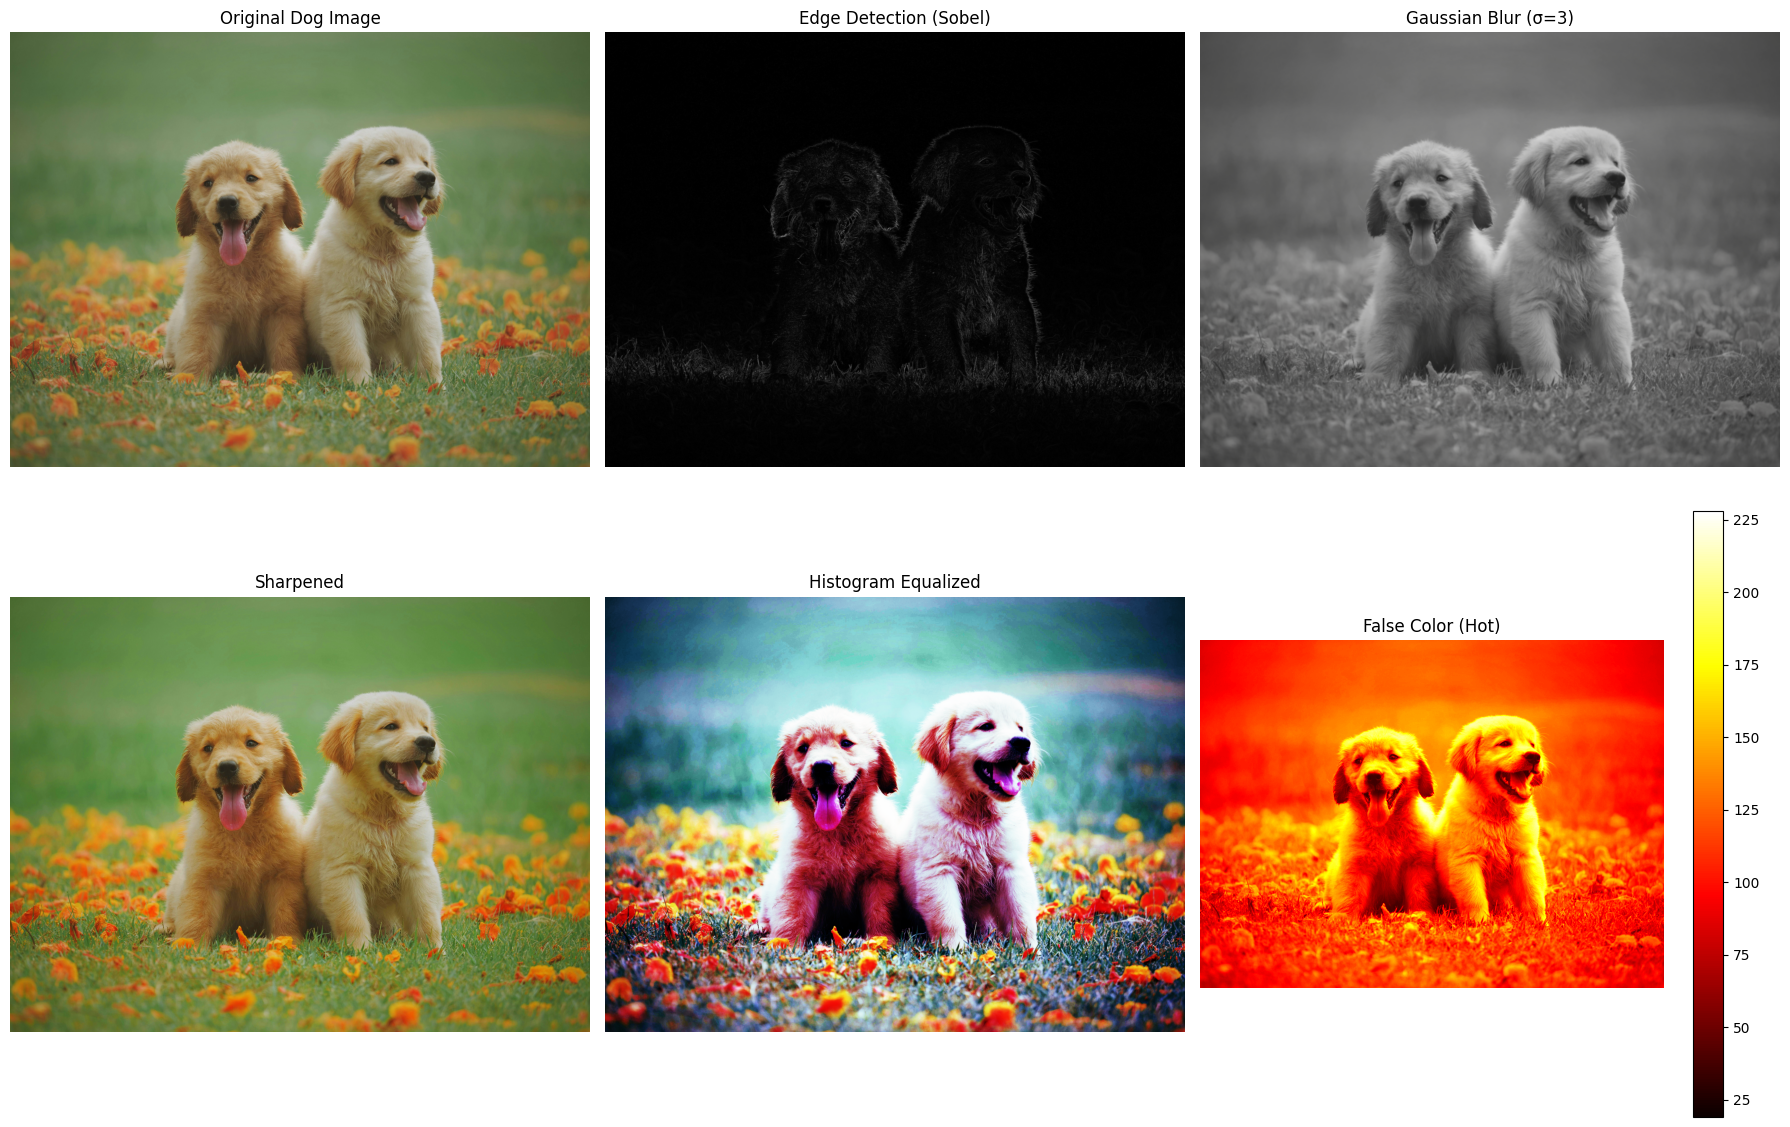

In [90]:
from scipy import ndimage

plt.figure(figsize=(18, 12))

# Original
plt.subplot(2, 3, 1)
plt.imshow(image_array)
plt.title('Original Dog Image')
plt.axis('off')

# Grayscale for processing
gray_img = np.dot(image_array[...,:3], [0.299, 0.587, 0.114])

# Edge detection (Sobel)
edges_x = ndimage.sobel(gray_img, axis=0)
edges_y = ndimage.sobel(gray_img, axis=1)
edges = np.hypot(edges_x, edges_y)
plt.subplot(2, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection (Sobel)')
plt.axis('off')

# Gaussian blur
blurred = ndimage.gaussian_filter(image_array, sigma=3)
plt.subplot(2, 3, 3)
plt.imshow(blurred)
plt.title('Gaussian Blur (σ=3)')
plt.axis('off')

# Sharpening
sharp = image_array.astype(float) + 0.5 * (image_array.astype(float) - blurred.astype(float))
sharp = np.clip(sharp, 0, 255).astype(np.uint8)
plt.subplot(2, 3, 4)
plt.imshow(sharp)
plt.title('Sharpened')
plt.axis('off')

# Histogram equalization per channel
def equalize_channel(channel):
    hist, bins = np.histogram(channel.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf[channel]

equalized = np.zeros_like(image_array)
for i in range(3):
    equalized[:, :, i] = equalize_channel(image_array[:, :, i])
    
plt.subplot(2, 3, 5)
plt.imshow(equalized)
plt.title('Histogram Equalized')
plt.axis('off')

# Apply colormap to grayscale
plt.subplot(2, 3, 6)
plt.imshow(gray_img, cmap='hot')
plt.title('False Color (Hot)')
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()
